In [1]:
from __future__ import print_function, division
import scipy

import keras
import tensorflow as tf
#import tensorflow-addons as tfa
#import tensorflow_addons as tfa
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout, Concatenate
from tensorflow.keras.layers import BatchNormalization, Activation, ZeroPadding2D
#from keras.layers.advanced_activations import LeakyReLU
from tensorflow.keras.layers import LeakyReLU,ReLU,Add, PReLU,add
from tensorflow.keras.layers import UpSampling2D, Conv2D, MaxPooling2D, Conv2DTranspose, SeparableConv2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.optimizers import schedules
from tensorflow.keras.layers import MaxPool2D,multiply,Lambda
from keras import backend as K


/Users/corpetti/miniforge3/envs/cnn_costarica/lib/python3.10/site-packages/flatbuffers/compat.py:19: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


Instructions for updating:
non-resource variables are not supported in the long term


### Test with efficientnet

In [4]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import RandomRotation,RandomTranslation,RandomFlip,RandomContrast


In [ ]:
backbone = EfficientNetB4(weights='imagenet',include_top=False,input_shape=input_shape)
input = backbone.input
start_neurons = 16

conv4 = backbone.layers[342].output
conv4 = LeakyReLU(alpha=0.1)(conv4)
pool4 = MaxPooling2D((2, 2))(conv4)
pool4 = Dropout(dropout_rate)(pool4)


In [41]:
def landslide_attention_efficientnet(img_shape_in,img_shape_dem,channels_out,gf):

    dropout_rate=0.
    def conv_block(inputs, filters, pool=True):
        x = Conv2D(filters, 3, padding="same")(inputs)

        x = BatchNormalization()(x)
        x = Activation("relu")(x)

        x = Conv2D(filters, 3, padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        if pool:
            p = MaxPool2D((2, 2))(x)
            return x, p
        else:
            return x
    

    def convolution_block(x, filters, size, strides=(1,1), padding='same', activation=True):
        x = Conv2D(filters, size, strides=strides, padding=padding)(x)
        x = BatchNormalization()(x)
        if activation == True:
            x = LeakyReLU(alpha=0.1)(x)
        return x

    def residual_block(blockInput, num_filters=16,pool=False):
        x = LeakyReLU(alpha=0.1)(blockInput)
        x = BatchNormalization()(x)
        blockInput = BatchNormalization()(blockInput)
        x = convolution_block(x, num_filters, (3,3) )
        x = convolution_block(x, num_filters, (3,3), activation=False)
        x = Add()([x, blockInput])
        if pool:
            p = MaxPool2D((2, 2))(x)
            return x, p
        else:
            return x
        return x



    def attention_block_2d(x, g, inter_channel):
        # theta_x(?,g_height,g_width,inter_channel)
        theta_x = Conv2D(inter_channel, [1, 1], strides=[1, 1])(x)
        # phi_g(?,g_height,g_width,inter_channel)
        phi_g = Conv2D(inter_channel, [1, 1], strides=[1, 1])(g)
        # f(?,g_height,g_width,inter_channel)
        f = Activation('relu')(add([theta_x, phi_g]))
        # psi_f(?,g_height,g_width,1)
        psi_f = Conv2D(1, [1, 1], strides=[1, 1])(f)
        rate = Activation('sigmoid')(psi_f)
        att_x = multiply([x, rate])
        return att_x

    def attention_up_and_concate(down_layer, layer):
        in_channel = down_layer.get_shape().as_list()[3]
        up = UpSampling2D(size=(2, 2))(down_layer)
        layer = attention_block_2d(x=layer, g=up, inter_channel=in_channel // 4)
        my_concat = Lambda(lambda x: K.concatenate([x[0], x[1]], axis=3))
        concate = my_concat([up, layer])
        return concate

    """ Encoder image """
    backbone = EfficientNetB4(weights='imagenet',include_top=False,input_shape=img_shape_in)
    input_ima = backbone.input

    conv4 = backbone.layers[342].output
    conv4 = LeakyReLU(alpha=0.1)(conv4)
    pool4 = MaxPooling2D((2, 2))(conv4)
    pool4 = Dropout(dropout_rate)(pool4)


    convm = Conv2D(gf * 32, (3, 3), activation=None, padding="same")(pool4)
    convm = residual_block(convm,gf * 32)
    convm = residual_block(convm,gf * 32)
    convm = LeakyReLU(alpha=0.1)(convm)
    
    """ Encoder dem """
    input_dem = Input(img_shape_dem,name="input_dem")
    xc = Conv2D(gf*1,(3, 3), activation=None, padding="same")(input_dem)
    x1d, p1d = residual_block(xc, gf/2,pool=True)
    p1d = Conv2D(gf*2,(3, 3), activation=None, padding="same")(p1d)
    x2d, p2d = residual_block(p1d, gf,pool=True )
    p2d = Conv2D(gf*4,(3, 3), activation=None, padding="same")(p2d)
    x3d, p3d = residual_block(p2d, gf * 2,pool=True)
    p3d = Conv2D(gf*8,(3, 3), activation=None, padding="same")(p3d)
    x4d, p4d = residual_block(p3d, gf * 3,pool=True)
    
    p4d = Conv2D(gf*16,(3, 3), activation=None, padding="same")(p4d)
    x5d, p5d = residual_block(p4d, gf * 4,pool=True)
    p5d = Conv2D(gf*16,(3, 3), activation=None, padding="same")(p5d)
    x6d, p6d = residual_block(p5d, gf * 5,pool=True)

    bridge = Concatenate(axis=-1,name="fusion_encoders")([convm, p6d])
#    bridge = p4d
    bridge = Conv2D(gf*16,(3, 3), activation=None, padding="same")(bridge)

    b1 = residual_block(bridge, gf * 8)

    
#    deconv4 = Conv2DTranspose(gf * 16, (3, 3), strides=(2, 2), padding="same")(convm)
#    uconv4 = concatenate([deconv4, conv4])
    uconv4 = attention_up_and_concate(convm,conv4)
    uconv4 = Dropout(dropout_rate)(uconv4)
    
    uconv4 = Conv2D(gf * 16, (3, 3), activation=None, padding="same")(uconv4)
    uconv4 = residual_block(uconv4,gf * 16)
    uconv4 = residual_block(uconv4,gf * 16)
    uconv4 = LeakyReLU(alpha=0.1)(uconv4)
    
#    deconv3 = Conv2DTranspose(gf * 8, (3, 3), strides=(2, 2), padding="same")(uconv4)
    conv3 = backbone.layers[154].output
#    uconv3 = concatenate([deconv3, conv3])    
    uconv3 = attention_up_and_concate(uconv4,conv3)
    uconv3 = Dropout(dropout_rate)(uconv3)
    
    uconv3 = Conv2D(gf * 8, (3, 3), activation=None, padding="same")(uconv3)
    uconv3 = residual_block(uconv3,gf * 8)
    uconv3 = residual_block(uconv3,gf * 8)
    uconv3 = LeakyReLU(alpha=0.1)(uconv3)

#    deconv2 = Conv2DTranspose(gf * 4, (3, 3), strides=(2, 2), padding="same")(uconv3)
    conv2 = backbone.layers[93].output
#    uconv2 = concatenate([deconv2, conv2])
    uconv2 = attention_up_and_concate(uconv3,conv2)        
    uconv2 = Dropout(0.1)(uconv2)

    uconv2 = Conv2D(gf * 4, (3, 3), activation=None, padding="same")(uconv2)
    uconv2 = residual_block(uconv2,gf * 4)
    uconv2 = residual_block(uconv2,gf * 4)
    uconv2 = LeakyReLU(alpha=0.1)(uconv2)
    
#    deconv1 = Conv2DTranspose(gf * 2, (3, 3), strides=(2, 2), padding="same")(uconv2)
    conv1 = backbone.layers[34].output
#    uconv1 = concatenate([deconv1, conv1])
    uconv1 = attention_up_and_concate(uconv2,conv1)        
    
    uconv1 = Dropout(0.1)(uconv1)
    uconv1 = Conv2D(gf * 2, (3, 3), activation=None, padding="same")(uconv1)
    uconv1 = residual_block(uconv1,gf * 2)
    uconv1 = residual_block(uconv1,gf * 2)
    uconv1 = LeakyReLU(alpha=0.1)(uconv1)
    
    uconv0 = Conv2DTranspose(gf * 1, (3, 3), strides=(2, 2), padding="same")(uconv1)   
    uconv0 = Dropout(0.1)(uconv0)
    uconv0 = Conv2D(gf * 1, (3, 3), activation=None, padding="same")(uconv0)
    uconv0 = residual_block(uconv0,gf * 1)
    uconv0 = residual_block(uconv0,gf * 1)
    uconv0 = LeakyReLU(alpha=0.1)(uconv0)
    
    uconv0 = Dropout(dropout_rate/2)(uconv0)
    output_layer = Conv2D(channels_out, (1,1), padding="same", activation="sigmoid")(uconv0)    
    return Model([input_ima,input_dem], output_layer)


In [45]:
img_shape_in=(256,256,3)
img_shape_dem=(256,256,1)
channels_out=1
gf=8
model=landslide_attention_efficientnet(img_shape_in,img_shape_dem,channels_out,gf)


In [60]:
backbone = EfficientNetB0(weights='imagenet',include_top=False,input_shape=img_shape_in)

In [61]:
backbone.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_23 (InputLayer)          [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_44 (Rescaling)       (None, 256, 256, 3)  0           ['input_23[0][0]']               
                                                                                                  
 normalization_22 (Normalizatio  (None, 256, 256, 3)  7          ['rescaling_44[0][0]']           
 n)                                                                                               
                                                                                     

                                                                                                  
 block2a_project_conv (Conv2D)  (None, 64, 64, 24)   2304        ['block2a_se_excite[0][0]']      
                                                                                                  
 block2a_project_bn (BatchNorma  (None, 64, 64, 24)  96          ['block2a_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block2b_expand_conv (Conv2D)   (None, 64, 64, 144)  3456        ['block2a_project_bn[0][0]']     
                                                                                                  
 block2b_expand_bn (BatchNormal  (None, 64, 64, 144)  576        ['block2b_expand_conv[0][0]']    
 ization)                                                                                         
          

                                                                                                  
 block3b_expand_bn (BatchNormal  (None, 32, 32, 240)  960        ['block3b_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block3b_expand_activation (Act  (None, 32, 32, 240)  0          ['block3b_expand_bn[0][0]']      
 ivation)                                                                                         
                                                                                                  
 block3b_dwconv (DepthwiseConv2  (None, 32, 32, 240)  6000       ['block3b_expand_activation[0][0]
 D)                                                              ']                               
                                                                                                  
 block3b_b

 block4b_dwconv (DepthwiseConv2  (None, 16, 16, 480)  4320       ['block4b_expand_activation[0][0]
 D)                                                              ']                               
                                                                                                  
 block4b_bn (BatchNormalization  (None, 16, 16, 480)  1920       ['block4b_dwconv[0][0]']         
 )                                                                                                
                                                                                                  
 block4b_activation (Activation  (None, 16, 16, 480)  0          ['block4b_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block4b_se_squeeze (GlobalAver  (None, 480)         0           ['block4b_activation[0][0]']     
 agePoolin

                                                                                                  
 block5a_activation (Activation  (None, 16, 16, 480)  0          ['block5a_bn[0][0]']             
 )                                                                                                
                                                                                                  
 block5a_se_squeeze (GlobalAver  (None, 480)         0           ['block5a_activation[0][0]']     
 agePooling2D)                                                                                    
                                                                                                  
 block5a_se_reshape (Reshape)   (None, 1, 1, 480)    0           ['block5a_se_squeeze[0][0]']     
                                                                                                  
 block5a_se_reduce (Conv2D)     (None, 1, 1, 20)     9620        ['block5a_se_reshape[0][0]']     
          

                                                                                                  
 block5c_se_expand (Conv2D)     (None, 1, 1, 672)    19488       ['block5c_se_reduce[0][0]']      
                                                                                                  
 block5c_se_excite (Multiply)   (None, 16, 16, 672)  0           ['block5c_activation[0][0]',     
                                                                  'block5c_se_expand[0][0]']      
                                                                                                  
 block5c_project_conv (Conv2D)  (None, 16, 16, 112)  75264       ['block5c_se_excite[0][0]']      
                                                                                                  
 block5c_project_bn (BatchNorma  (None, 16, 16, 112)  448        ['block5c_project_conv[0][0]']   
 lization)                                                                                        
          

                                                                                                  
 block6b_project_bn (BatchNorma  (None, 8, 8, 192)   768         ['block6b_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block6b_drop (Dropout)         (None, 8, 8, 192)    0           ['block6b_project_bn[0][0]']     
                                                                                                  
 block6b_add (Add)              (None, 8, 8, 192)    0           ['block6b_drop[0][0]',           
                                                                  'block6a_project_bn[0][0]']     
                                                                                                  
 block6c_expand_conv (Conv2D)   (None, 8, 8, 1152)   221184      ['block6b_add[0][0]']            
          

                                                                                                  
 block6d_add (Add)              (None, 8, 8, 192)    0           ['block6d_drop[0][0]',           
                                                                  'block6c_add[0][0]']            
                                                                                                  
 block7a_expand_conv (Conv2D)   (None, 8, 8, 1152)   221184      ['block6d_add[0][0]']            
                                                                                                  
 block7a_expand_bn (BatchNormal  (None, 8, 8, 1152)  4608        ['block7a_expand_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 block7a_expand_activation (Act  (None, 8, 8, 1152)  0           ['block7a_expand_bn[0][0]']      
 ivation) 

In [85]:
def num_layer(model,name_layer):
    for i in range(len(model.layers)):        
        if name_layer not in model.layers[i].name:
            continue
        n=i
        print('number layer ',i,model.layers[i].name)
    return n

nconv0= num_layer(backbone,'normalization')
nconv1= num_layer(backbone,'block1a_activation')
nconv2= num_layer(backbone,'block2a_activation')
nconv3= num_layer(backbone,'block3a_activation')
nconv4= num_layer(backbone,'block4a_activation')
backbone.input[0]
input_dem = Input(img_shape_dem,name="input_dem")
print(input_dem)
print(type(input_dem))
print(backbone.input[0])
print(type(backbone.input[0]))
print(backbone.input)
print(type(backbone.input))


number layer  2 normalization_22
number layer  10 block1a_activation
number layer  24 block2a_activation
number layer  53 block3a_activation
number layer  82 block4a_activation
Tensor("input_dem_27:0", shape=(?, 256, 256, 1), dtype=float32)
<class 'tensorflow.python.framework.ops.Tensor'>
Tensor("strided_slice_7:0", shape=(256, 256, 3), dtype=float32)
<class 'tensorflow.python.framework.ops.Tensor'>
Tensor("input_23:0", shape=(?, 256, 256, 3), dtype=float32)
<class 'tensorflow.python.framework.ops.Tensor'>


In [71]:
def landslide_attention_efficientnet(img_shape_in,img_shape_dem,channels_out,gf,concaten_dem_only,concaten_ima_only,backbone=backbone):
    dropout_rate=0.
    def conv_block(inputs, filters, pool=True):
        x = Conv2D(filters, 3, padding="same")(inputs)

        x = BatchNormalization()(x)
        x = Activation("relu")(x)

        x = Conv2D(filters, 3, padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        if pool:
            p = MaxPool2D((2, 2))(x)
            return x, p
        else:
            return x
    

    def convolution_block(x, filters, size, strides=(1,1), padding='same', activation=True):
        x = Conv2D(filters, size, strides=strides, padding=padding)(x)
        x = BatchNormalization()(x)
        if activation == True:
            x = LeakyReLU(alpha=0.1)(x)
        return x

    def residual_block(blockInput, num_filters=16,pool=False):
        x = LeakyReLU(alpha=0.1)(blockInput)
        x = BatchNormalization()(x)
        blockInput = BatchNormalization()(blockInput)
        x = convolution_block(x, num_filters, (3,3) )
        x = convolution_block(x, num_filters, (3,3), activation=False)
        x = Add()([x, blockInput])
        if pool:
            p = MaxPool2D((2, 2))(x)
            return x, p
        else:
            return x
        return x



    def attention_block_2d(x, g, inter_channel):
        # theta_x(?,g_height,g_width,inter_channel)
        theta_x = Conv2D(inter_channel, [1, 1], strides=[1, 1])(x)
        # phi_g(?,g_height,g_width,inter_channel)
        phi_g = Conv2D(inter_channel, [1, 1], strides=[1, 1])(g)
        # f(?,g_height,g_width,inter_channel)
        f = Activation('relu')(add([theta_x, phi_g]))
        # psi_f(?,g_height,g_width,1)
        psi_f = Conv2D(1, [1, 1], strides=[1, 1])(f)
        rate = Activation('sigmoid')(psi_f)
        att_x = multiply([x, rate])
        return att_x

    def attention_up_and_concate(down_layer, layer):
        in_channel = down_layer.get_shape().as_list()[3]
        up = UpSampling2D(size=(2, 2))(down_layer)
        layer = attention_block_2d(x=layer, g=up, inter_channel=in_channel // 4)
        my_concat = Lambda(lambda x: K.concatenate([x[0], x[1]], axis=3))
        concate = my_concat([up, layer])
        return concate

    """ Encoder image """
    input_ima = backbone.input
    nconv0= num_layer(backbone,'normalization')
    nconv1= num_layer(backbone,'block1a_activation')
    nconv2= num_layer(backbone,'block2a_activation')
    nconv3= num_layer(backbone,'block3a_activation')
    nconv4= num_layer(backbone,'block4a_activation')
    
    x1i = backbone.layers[nconv0].output # 86
    x2i = backbone.layers[nconv1].output # 86
    x3i = backbone.layers[nconv2].output # 144
    x4i = backbone.layers[nconv3].output # 240
    x5i = backbone.layers[nconv4].output # 480

    
    """ Encoder dem """
    input_dem = Input(img_shape_dem,name="input_dem")
    xc = Conv2D(gf*1,(3, 3), activation=None, padding="same")(input_dem)
    x1d, p1d = residual_block(xc, gf,pool=True)
    p1d = Conv2D(gf*2,(3, 3), activation=None, padding="same")(p1d)
    x2d, p2d = residual_block(p1d, gf*2,pool=True )
    p2d = Conv2D(gf*4,(3, 3), activation=None, padding="same")(p2d)
    x3d, p3d = residual_block(p2d, gf * 4,pool=True)
    p3d = Conv2D(gf*8,(3, 3), activation=None, padding="same")(p3d)
    x4d, p4d = residual_block(p3d, gf * 8,pool=True)
    
    """ Bridge"""
    bridge = Concatenate(axis=-1,name="fusion_encoders")([x5i, p4d])
    bridge = Conv2D(gf*8,(3, 3), activation=None, padding="same")(bridge)
    bridge = residual_block(bridge, gf * 8)

    if concaten_dem_only is True:
        x = attention_up_and_concate(bridge,x4d)
        x = Conv2D(gf * 8, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 8)
        x = residual_block(x,gf * 8)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,x3d)
        x = Conv2D(gf * 4, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 4)
        x = residual_block(x,gf * 4)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,x2d)
        x = Conv2D(gf * 2, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 2)
        x = residual_block(x,gf * 2)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,x1d)
        x = Conv2D(gf , (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf )
        x = residual_block(x,gf )
        x = LeakyReLU(alpha=0.1)(x)
        
        
    elif concaten_ima_only is True:
        """ Concaten Image only """
        x = attention_up_and_concate(bridge,x4i)
        x = Conv2D(gf * 8, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 8)
        x = residual_block(x,gf * 8)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,x3i)
        x = Conv2D(gf * 4, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 4)
        x = residual_block(x,gf * 4)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,x2i)
        x = Conv2D(gf * 2, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 2)
        x = residual_block(x,gf * 2)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,x1i)
        x = Conv2D(gf , (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf )
        x = residual_block(x,gf )
        x = LeakyReLU(alpha=0.1)(x)
    else:
        """ Concaten Image and DEM """
        x = attention_up_and_concate(bridge,Concatenate(axis=-1)([x4i, x4d]))
        x = Conv2D(gf * 8, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 8)
        x = residual_block(x,gf * 8)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,Concatenate(axis=-1)([x3i, x3d]))
        x = Conv2D(gf * 4, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 4)
        x = residual_block(x,gf * 4)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,Concatenate(axis=-1)([x2i, x2d]))
        x = Conv2D(gf * 2, (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf * 2)
        x = residual_block(x,gf * 2)
        x = LeakyReLU(alpha=0.1)(x)

        x = attention_up_and_concate(x,Concatenate(axis=-1)([x1i, x1d]))
        x = Conv2D(gf , (3, 3), activation=None, padding="same")(x)
        x = residual_block(x,gf )
        x = residual_block(x,gf )
        x = LeakyReLU(alpha=0.1)(x)
        
    x = Conv2DTranspose(gf * 1, (3, 3), strides=(2, 2), padding="same")(x)   
    x = Dropout(0.1)(x)
    x = Conv2D(gf * 1, (3, 3), activation=None, padding="same")(x)
    x = residual_block(x,gf * 1)
    x = residual_block(x,gf * 1)
    x = LeakyReLU(alpha=0.1)(x)
    
    x = Dropout(dropout_rate/2)(x)
    output_layer = Conv2D(channels_out, (1,1), padding="same", activation="sigmoid")(x)    
    return Model([input_ima,input_dem], output_layer)


In [76]:
img_shape_in=(256,256,3)
img_shape_dem=(256,256,1)
channels_out=1
gf=8
concaten_dem_only=False
concaten_ima_only=False
model= landslide_attention_efficientnet(img_shape_in,img_shape_dem,channels_out,gf,concaten_dem_only,concaten_ima_only)

number layer  2 normalization_22
number layer  10 block1a_activation
number layer  24 block2a_activation
number layer  53 block3a_activation
number layer  82 block4a_activation


In [77]:
model.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_23 (InputLayer)          [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_44 (Rescaling)       (None, 256, 256, 3)  0           ['input_23[0][0]']               
                                                                                                  
 normalization_22 (Normalizatio  (None, 256, 256, 3)  7          ['rescaling_44[0][0]']           
 n)                                                                                               
                                                                                            

                                                                                                  
 block2a_project_conv (Conv2D)  (None, 64, 64, 24)   2304        ['block2a_se_excite[0][0]']      
                                                                                                  
 block2a_project_bn (BatchNorma  (None, 64, 64, 24)  96          ['block2a_project_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 block2b_expand_conv (Conv2D)   (None, 64, 64, 144)  3456        ['block2a_project_bn[0][0]']     
                                                                                                  
 block2b_expand_bn (BatchNormal  (None, 64, 64, 144)  576        ['block2b_expand_conv[0][0]']    
 ization)                                                                                         
          

                                                                                                  
 add_288 (Add)                  (None, 256, 256, 8)  0           ['batch_normalization_963[0][0]',
                                                                  'batch_normalization_961[0][0]']
                                                                                                  
 block3a_bn (BatchNormalization  (None, 32, 32, 144)  576        ['block3a_dwconv[0][0]']         
 )                                                                                                
                                                                                                  
 max_pooling2d_119 (MaxPooling2  (None, 128, 128, 8)  0          ['add_288[0][0]']                
 D)                                                                                               
                                                                                                  
 block3a_a

                                                                                                  
 block3b_activation (Activation  (None, 32, 32, 240)  0          ['block3b_bn[0][0]']             
 )                                                                                                
                                                                                                  
 conv2d_807 (Conv2D)            (None, 64, 64, 32)   9248        ['batch_normalization_968[0][0]']
                                                                                                  
 block3b_se_squeeze (GlobalAver  (None, 240)         0           ['block3b_activation[0][0]']     
 agePooling2D)                                                                                    
                                                                                                  
 batch_normalization_970 (Batch  (None, 64, 64, 32)  128         ['conv2d_807[0][0]']             
 Normaliza

 block4a_bn (BatchNormalization  (None, 16, 16, 240)  960        ['block4a_dwconv[0][0]']         
 )                                                                                                
                                                                                                  
 add_291 (Add)                  (None, 32, 32, 64)   0           ['batch_normalization_975[0][0]',
                                                                  'batch_normalization_973[0][0]']
                                                                                                  
 block4a_activation (Activation  (None, 16, 16, 240)  0          ['block4a_bn[0][0]']             
 )                                                                                                
                                                                                                  
 max_pooling2d_122 (MaxPooling2  (None, 16, 16, 64)  0           ['add_291[0][0]']                
 D)       

                                                                                                  
 batch_normalization_981 (Batch  (None, 32, 32, 64)  256         ['conv2d_818[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 add_294 (Add)                  (None, 32, 32, 64)   0           ['batch_normalization_983[0][0]',
                                                                  'batch_normalization_981[0][0]']
                                                                                                  
 leaky_re_lu_577 (LeakyReLU)    (None, 32, 32, 64)   0           ['add_294[0][0]']                
                                                                                                  
 batch_normalization_984 (Batch  (None, 32, 32, 64)  256         ['leaky_re_lu_577[0][0]']        
 Normaliza

                                                                                                  
 batch_normalization_992 (Batch  (None, 64, 64, 32)  128         ['leaky_re_lu_582[0][0]']        
 Normalization)                                                                                   
                                                                                                  
 conv2d_829 (Conv2D)            (None, 64, 64, 32)   9248        ['batch_normalization_992[0][0]']
                                                                                                  
 batch_normalization_994 (Batch  (None, 64, 64, 32)  128         ['conv2d_829[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 leaky_re_lu_583 (LeakyReLU)    (None, 64, 64, 32)   0           ['batch_normalization_994[0][0]']
          

 hNormalization)                )                                                                 
                                                                                                  
 conv2d_837 (Conv2D)            (None, 128, 128, 16  2320        ['batch_normalization_1000[0][0]'
                                )                                ]                                
                                                                                                  
 batch_normalization_1002 (Batc  (None, 128, 128, 16  64         ['conv2d_837[0][0]']             
 hNormalization)                )                                                                 
                                                                                                  
 leaky_re_lu_588 (LeakyReLU)    (None, 128, 128, 16  0           ['batch_normalization_1002[0][0]'
                                )                                ]                                
          

 hNormalization)                                                                                  
                                                                                                  
 conv2d_845 (Conv2D)            (None, 256, 256, 8)  584         ['batch_normalization_1008[0][0]'
                                                                 ]                                
                                                                                                  
 batch_normalization_1010 (Batc  (None, 256, 256, 8)  32         ['conv2d_845[0][0]']             
 hNormalization)                                                                                  
                                                                                                  
 leaky_re_lu_593 (LeakyReLU)    (None, 256, 256, 8)  0           ['batch_normalization_1010[0][0]'
                                                                 ]                                
          

                                                                                                  
 leaky_re_lu_599 (LeakyReLU)    (None, 512, 512, 8)  0           ['add_306[0][0]']                
                                                                                                  
 dropout_67 (Dropout)           (None, 512, 512, 8)  0           ['leaky_re_lu_599[0][0]']        
                                                                                                  
 conv2d_852 (Conv2D)            (None, 512, 512, 1)  9           ['dropout_67[0][0]']             
                                                                                                  
Total params: 894,630
Trainable params: 887,231
Non-trainable params: 7,399
__________________________________________________________________________________________________


# Creation of the neural network model



In [8]:
def landslide_attention(img_shape_in,img_shape_dem,channels_out,gf):
    def conv_block(inputs, filters, pool=True):
        x = Conv2D(filters, 3, padding="same")(inputs)

        x = BatchNormalization()(x)
        x = Activation("relu")(x)

        x = Conv2D(filters, 3, padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        if pool:
            p = MaxPool2D((2, 2))(x)
            return x, p
        else:
            return x

    def attention_block_2d(x, g, inter_channel):
        # theta_x(?,g_height,g_width,inter_channel)
        theta_x = Conv2D(inter_channel, [1, 1], strides=[1, 1])(x)
        # phi_g(?,g_height,g_width,inter_channel)
        phi_g = Conv2D(inter_channel, [1, 1], strides=[1, 1])(g)
        # f(?,g_height,g_width,inter_channel)
        f = Activation('relu')(add([theta_x, phi_g]))
        # psi_f(?,g_height,g_width,1)
        psi_f = Conv2D(1, [1, 1], strides=[1, 1])(f)
        rate = Activation('sigmoid')(psi_f)
        att_x = multiply([x, rate])
        return att_x

    def attention_up_and_concate(down_layer, layer):
        in_channel = down_layer.get_shape().as_list()[3]
        up = UpSampling2D(size=(2, 2))(down_layer)
        layer = attention_block_2d(x=layer, g=up, inter_channel=in_channel // 4)
        my_concat = Lambda(lambda x: K.concatenate([x[0], x[1]], axis=3))
        concate = my_concat([up, layer])
        return concate

    inputs_ima = Input(img_shape_in,name="input_image")
    """ Encoder image """
    x1i, p1i = conv_block(inputs_ima, gf)
    x2i, p2i = conv_block(p1i, gf * 2)
    x3i, p3i = conv_block(p2i, gf * 3)
    x4i, p4i = conv_block(p3i, gf * 4)
        
    inputs_dem = Input(img_shape_dem,name="input_dem")
    """ Encoder dem """
    x1d, p1d = conv_block(inputs_dem, gf/2)
    x2d, p2d = conv_block(p1d, gf )
    x3d, p3d = conv_block(p2d, gf * 2)
    x4d, p4d = conv_block(p3d, gf * 3)

    bridge = Concatenate(axis=-1,name="fusion_encoders")([p4i, p4d])
#    bridge = p4d
    b1 = conv_block(bridge, gf * 8,pool=False)

    """ Decoder """
    x = attention_up_and_concate(b1,Concatenate(axis=-1)([x4i, x4d]))
    x = conv_block(x, 4 * gf, pool=False)
    x = attention_up_and_concate(x, Concatenate(axis=-1)([x3i, x3d]))
    x = conv_block(x, 3 * gf, pool=False)
    x = attention_up_and_concate(x,Concatenate(axis=-1)([x2i, x2d]))
    x = conv_block(x, 2 * gf, pool=False)
    x = attention_up_and_concate(x,Concatenate(axis=-1)([x1i, x1d]))
    x = conv_block(x, 2 * gf, pool=False)


    """ Output layer """
    output = Conv2D(channels_out, 1, padding="same", activation="sigmoid")(x)
    return Model([inputs_ima,inputs_dem], output)


In [9]:
img_shape_in=(256,256,3)
img_shape_dem=(256,256,1)
img_shape_out=(256,256,1)
gf=32
channels_out=1


In [10]:
model=landslide_attention(img_shape_in,img_shape_dem,channels_out,gf)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 input_dem (InputLayer)         [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_39 (Conv2D)             (None, 256, 256, 32  896         ['input_image[0][0]']            
                                )                                                           

                                                                                                  
 activation_45 (Activation)     (None, 128, 128, 32  0           ['batch_normalization_37[0][0]'] 
                                )                                                                 
                                                                                                  
 max_pooling2d_9 (MaxPooling2D)  (None, 64, 64, 64)  0           ['activation_37[0][0]']          
                                                                                                  
 max_pooling2d_13 (MaxPooling2D  (None, 64, 64, 32)  0           ['activation_45[0][0]']          
 )                                                                                                
                                                                                                  
 conv2d_43 (Conv2D)             (None, 64, 64, 96)   55392       ['max_pooling2d_9[0][0]']        
          

 ormalization)                                                                                    
                                                                                                  
 activation_50 (Activation)     (None, 16, 16, 256)  0           ['batch_normalization_42[0][0]'] 
                                                                                                  
 conv2d_56 (Conv2D)             (None, 16, 16, 256)  590080      ['activation_50[0][0]']          
                                                                                                  
 batch_normalization_43 (BatchN  (None, 16, 16, 256)  1024       ['conv2d_56[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_51 (Activation)     (None, 16, 16, 256)  0           ['batch_normalization_43[0][0]'] 
          

 ormalization)                                                                                    
                                                                                                  
 activation_59 (Activation)     (None, 64, 64, 96)   0           ['batch_normalization_47[0][0]'] 
                                                                                                  
 up_sampling2d_6 (UpSampling2D)  (None, 128, 128, 96  0          ['activation_59[0][0]']          
                                )                                                                 
                                                                                                  
 concatenate_6 (Concatenate)    (None, 128, 128, 96  0           ['activation_37[0][0]',          
                                )                                 'activation_45[0][0]']          
                                                                                                  
 conv2d_67

                                                                                                  
 activation_66 (Activation)     (None, 256, 256, 64  0           ['batch_normalization_50[0][0]'] 
                                )                                                                 
                                                                                                  
 conv2d_76 (Conv2D)             (None, 256, 256, 64  36928       ['activation_66[0][0]']          
                                )                                                                 
                                                                                                  
 batch_normalization_51 (BatchN  (None, 256, 256, 64  256        ['conv2d_76[0][0]']              
 ormalization)                  )                                                                 
                                                                                                  
 activatio

In [ ]:
from keras.utils.vis_utils import plot_model
# fonction plot_model : on donne un modèle, le nom du fichier de sauvegarde, et deux booleens qui disent qu'on regarde les tailles et les noms des layers
plot_model(model, to_file='fusion.png', show_shapes=True, show_layer_names=True)


In [172]:
hist=np.load('./raw_dataset_gf_16_lr0.001/history.npy',allow_pickle=True).item()

In [173]:
hist

{'loss': [6.221826828759292,
  5.688184140057399,
  5.447289000297415,
  5.2209470827004,
  5.144690094322994,
  4.936698068832529,
  4.843044046697946,
  4.766116512232814,
  4.723936720141049,
  4.543132251706616,
  4.572725577601071,
  4.51840767572666,
  4.346541949387254,
  4.247487308650181,
  4.314937036612938,
  4.106170305918003,
  4.0904575750745575,
  4.102555322236028,
  3.9861255596423972,
  3.870027052945104,
  3.8209777515510033,
  3.849889407897818,
  3.8563841468301314,
  3.7071472252237387,
  3.6828682545957894,
  3.593441266438057,
  3.52060362593881,
  3.4856996361551613,
  3.336386423686455,
  3.429710701621812,
  3.215083929999121,
  3.2952021411780654,
  3.1129600292649764,
  2.9940474495805542,
  3.0526850418797853,
  2.862398337701271,
  2.85835835029339,
  2.6748593110462715,
  2.685806724531897,
  2.6308945160487602,
  2.4798083110102294,
  2.4306024878189483,
  2.377255670983216,
  2.2878010982069474,
  2.0591943711042404,
  2.159518525004387,
  2.1206729961

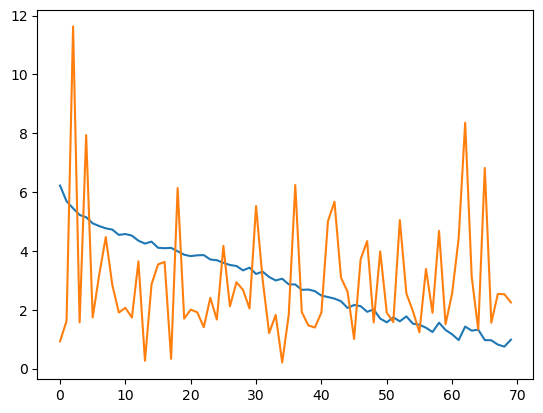

In [174]:
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])

In [108]:
hist['loss']

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [144]:
im1=np.ones((10,10,3))
im2=np.ones((10,10,1))*2
im3=np.ones((10,10,1))*3
im4=np.ones((10,10,1))*4


In [157]:
#im2=np.repeat(im2.reshape(10, 10, 1), 3, axis=2)
im3=np.repeat(im3.reshape(10, 10, 1), 3, axis=2)
im4=np.repeat(im4.reshape(10, 10, 1), 3, axis=2)

In [158]:
imc1=np.concatenate((im3,im4),axis=1)
imc2=np.concatenate((im1,im2),axis=1)

In [163]:
imc=np.concatenate((imc1,imc2),axis=0)

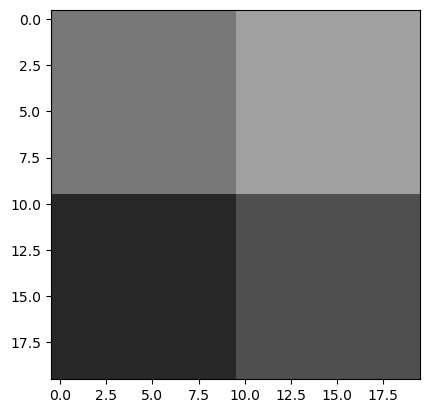

In [165]:
plt.imshow(np.uint8(imc*40))